## **Objective**  


### Develop a machine learning-based fraud detection system for Finex Bank that can accurately identify fraudulent credit card transactions using transaction and customer behavior data, minimize financial losses caused by fraud, improve fraud detection rates through feature engineering and predictive modeling, and evaluate the potential business savings through cost-benefit analysis


## **Dataset information**


| Attribute | Value |
|------------|--------|
| Number of Records | 1,296,675 |
| Number of Features | 23 |
| Target Variable | `is_fraud` |
| Numerical Columns | 11 |
| Categorical Columns | 12 |
| Missing Values | 0 |
| Memory Usage | 227.5 MB |

## Feature Description

| Column Name | Data Type | Description |
|------------|------------|-------------|
| Unnamed: 0 | int64 | Row index |
| trans_date_trans_time | object | Transaction date and time |
| cc_num | int64 | Credit card number |
| merchant | object | Merchant name |
| category | object | Transaction category |
| amt | float64 | Transaction amount |
| first | object | Customer first name |
| last | object | Customer last name |
| gender | object | Customer gender |
| street | object | Customer street address |
| city | object | Customer city |
| state | object | Customer state |
| zip | int64 | ZIP code |
| lat | float64 | Customer latitude |
| long | float64 | Customer longitude |
| city_pop | int64 | Population of customer's city |
| job | object | Customer occupation |
| dob | object | Date of birth |
| trans_num | object | Unique transaction ID |
| unix_time | int64 | Unix timestamp |
| merch_lat | float64 | Merchant latitude |
| merch_long | float64 | Merchant longitude |
| is_fraud | int64 | Fraud label (0 = Legitimate, 1 = Fraudulent) |

## Data Type Summary

| Data Type | Count |
|------------|--------|
| int64 | 6 |
| float64 | 5 |
| object | 12 |
| Total Columns | 23 |

## **Import Libraries**

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Google Drive Connection**

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Load Dataset**

In [72]:
df_train = pd.read_csv('/content/drive/MyDrive/Credit Card Fraud Datasets/fraudTrain.csv')
df_train.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [73]:
df_test = pd.read_csv('/content/drive/MyDrive/Credit Card Fraud Datasets/fraudTest.csv')
df_test.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


## **Data Handling**

### Both data sets combine for analyzing

In [74]:
# Concatinating two data sets df_train and df_test
df = pd.concat([df_train,df_test],ignore_index = True)
df.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


## **Understand data**

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

## **dataset shapes**

In [76]:
df.shape

(1852394, 23)

### **describe**

In [77]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,5.371934e+05,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,3.669110e+05,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,2.315490e+05,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,4.630980e+05,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,8.335758e+05,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


### **find null values**

In [78]:
# Check for columns with missing values and display their null counts
df.isnull().sum()[df.isnull().sum() > 0]

,0


### **find duplicates**

In [79]:
# # Check the total number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

## **Data Preprocessing**

### **Remove personally identifiable and non-informative columns**

In [80]:
df.drop(columns=['first','last','Unnamed: 0','unix_time','zip','trans_num'],inplace=True)

### **convert dtypes**

In [81]:
# # Convert transaction date and birth date columns to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob']).dt.date

In [82]:
df.head(5)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,46.2306,-112.1138,1939,Patent attorney,1967-01-12,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,38.674999,-78.632459,0


In [83]:
df.drop(columns=['street'],inplace=True)

## **Exploratory Data Analysis (EDA)**

### dividing category columns and numerical columns

In [84]:
# Dividing category columns and numerical columsn for analyzing separately
cat_col = df.select_dtypes(include=['object','datetime64']).columns
num_col = df.select_dtypes(include=['number']).columns

In [85]:
df[cat_col].head(5)

,trans_date_trans_time,merchant,category,gender,city,state,job,dob
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,F,Moravian Falls,NC,"Psychologist, counselling",1988-03-09
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Orient,WA,Special educational needs teacher,1978-06-21
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,M,Malad City,ID,Nature conservation officer,1962-01-19
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,M,Boulder,MT,Patent attorney,1967-01-12
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,M,Doe Hill,VA,Dance movement psychotherapist,1986-03-28


In [86]:
df[num_col].head(5)

,cc_num,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
0,2703186189652095,4.97,36.0788,-81.1781,3495,36.011293,-82.048315,0
1,630423337322,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0
2,38859492057661,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0
3,3534093764340240,45.00,46.2306,-112.1138,1939,47.034331,-112.561071,0
4,375534208663984,41.96,38.4207,-79.4629,99,38.674999,-78.632459,0


### **Check the distribution of fraudulent and non-fraudulent transactions**

In [87]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,1842743
1,9651


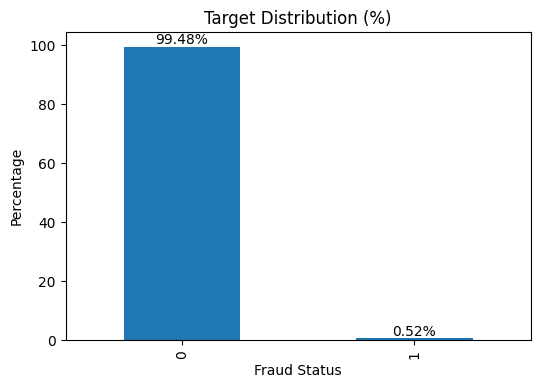

In [88]:
# Visualize the percentage distribution of fraud and non-fraud transactions
target_pct = df['is_fraud'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
ax = target_pct.plot(kind='bar')

for i, v in enumerate(target_pct):
    ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.title('Target Distribution (%)')
plt.xlabel('Fraud Status')
plt.ylabel('Percentage')
plt.show()

**heavily class imbalance problem**  
The target variable is highly imbalanced. Non-fraud transactions account for 99.48% of the dataset, while fraud transactions account for only 0.52%. This imbalance may bias machine learning models toward the majority class, making accuracy an unreliable evaluation metric.

### **Numerical Distribution**

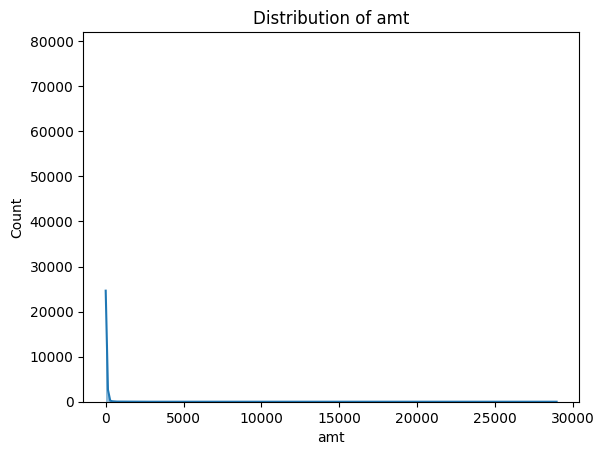

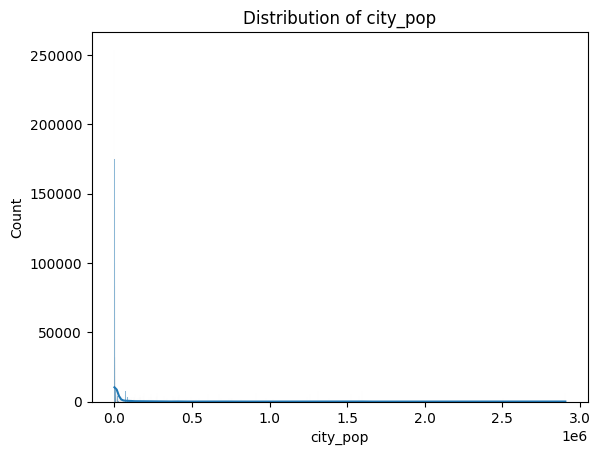

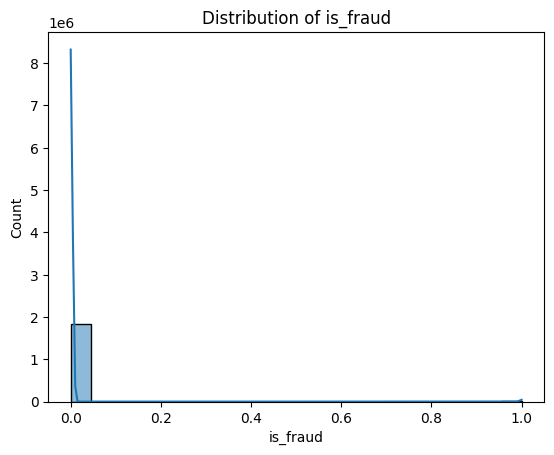

In [89]:
# Visualize the distribution of numerical features using histograms and KDE plots
for col in ['amt', 'city_pop', 'is_fraud']:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

logtransformation to amount column

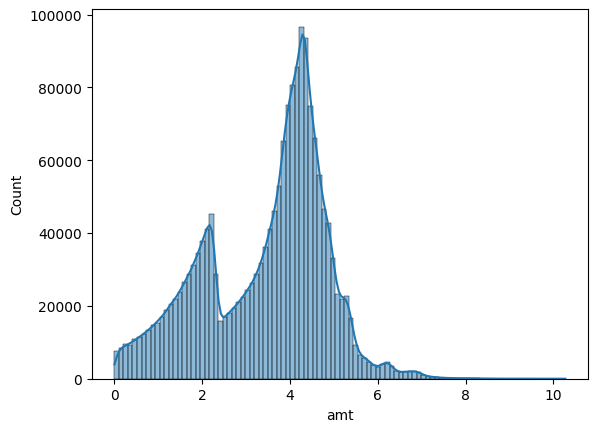

In [90]:
# Visualize the distribution of transaction amounts after log transformation
sns.histplot(np.log(df['amt']), kde=True, bins=100)
plt.show()

In [91]:
# Calculate skewness for selected numerical features
skew_df = df[['amt','city_pop','is_fraud']].skew().reset_index()
skew_df.columns = ['feature', 'skew_value']

In [92]:
# Categorize features based on their skewness values
def skew_type(x):
    if x > 1:
        return "Highly Right Skewed"
    elif x > 0.5:
        return "Moderately Right Skewed"
    elif x < -1:
        return "Highly Left Skewed"
    elif x < -0.5:
        return "Moderately Left Skewed"
    else:
        return "Approximately Symmetric"

skew_df['Skew Type'] = skew_df['skew_value'].apply(skew_type)

In [93]:
skew_df

,feature,skew_value,Skew Type
0,amt,40.812809,Highly Right Skewed
1,city_pop,5.590805,Highly Right Skewed
2,is_fraud,13.745675,Highly Right Skewed


The skewness analysis shows that the amt feature is highly right-skewed (40.81), indicating that most transactions involve small amounts while a few transactions involve extremely large amounts. The city_pop feature is also highly right-skewed (5.59), suggesting that most transactions occur in smaller cities, with a few cities having very large populations. Due to the extreme skewness in amt, a log transformation was applied to reduce skewness and improve the distribution.

In [94]:
# Calculate fraud rates for each city and retain only cities with fraudulent transactions
fraud_rate = (
    df.groupby('city')['is_fraud']
      .mean()
      .reset_index()
)

fraud_rate = fraud_rate[fraud_rate['is_fraud'] > 0]
fraud_rate

,city,is_fraud
0,Achille,0.017568
1,Acworth,0.004444
2,Adams,0.016238
3,Afton,0.005457
4,Akron,0.012278
...,...,...
900,Wittenberg,0.016327
902,Woodville,0.003422
903,Yellowstone National Park,0.016173
904,Zaleski,0.005467


### **Fraud rate by top 10 cities**

In [95]:
# groupby city
city_stats = df.groupby('city').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum')
)

# calcualte fraud rate
city_stats['fraud_rate'] = (
    city_stats['fraud_count']
    / city_stats['total_transactions']
) * 100

# filter atlest 50 transactions
city_stats = city_stats[
    city_stats['total_transactions'] >= 50
]

city_stats

,total_transactions,fraud_count,fraud_rate
city,,,
Achille,740,13,1.756757
Acworth,2925,13,0.444444
Adams,739,12,1.623816
Afton,2932,16,0.545703
Akron,733,9,1.227831
...,...,...,...
Woods Cross,730,0,0.000000
Woodville,2922,10,0.342231
Yellowstone National Park,742,12,1.617251


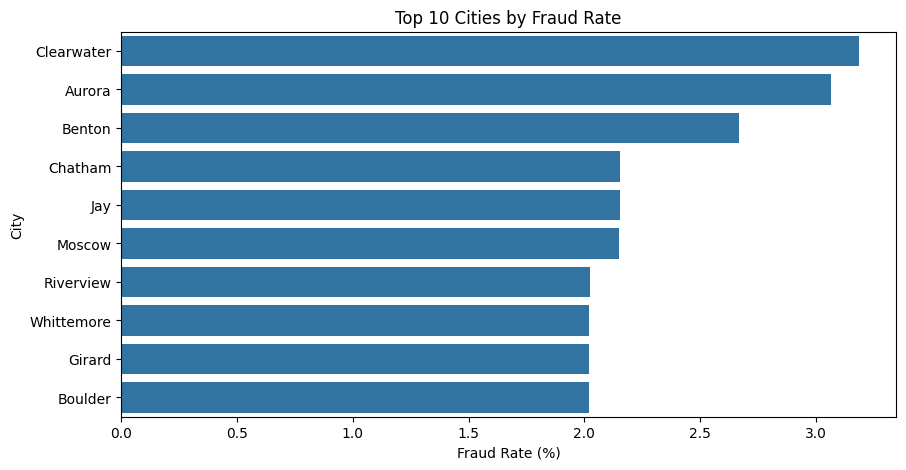

In [96]:
# Visualize the top 10 cities with the highest fraud rates
top10 = city_stats.sort_values(
    by='fraud_rate',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top10,
    x='fraud_rate',
    y=top10.index
)

plt.title('Top 10 Cities by Fraud Rate')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('City')
plt.show()

Fraud rates vary across cities, indicating geographical differences in fraudulent activity. Clearwater and Aurora show the highest fraud rates, exceeding 3%, while the remaining top cities have fraud rates around 2%–2.7%.

### **fraud rate by gender**

In [97]:
# Calculate transaction counts, fraud counts, and fraud rates by gender
gender_stats = df.groupby('gender').agg(
    total_transactions=("is_fraud", "count"),
    fraud_count=("is_fraud", "sum")
)

gender_stats['fraud_rate'] = (
    gender_stats['fraud_count']
    / gender_stats['total_transactions']
) * 100

gender_stats

,total_transactions,fraud_count,fraud_rate
gender,,,
F,1014749,4899,0.482779
M,837645,4752,0.567305


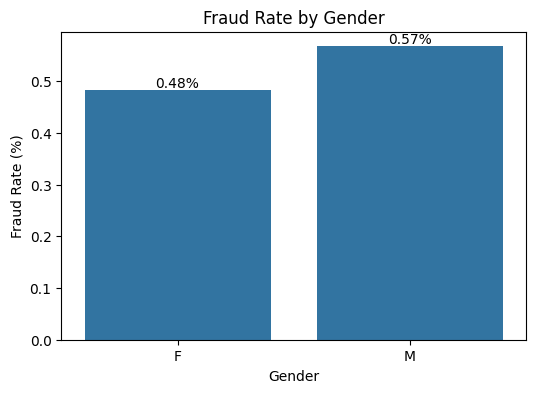

In [98]:
# Visualize fraud rates across genders
plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=gender_stats.index,
    y=gender_stats['fraud_rate']
)

for i, v in enumerate(gender_stats['fraud_rate']):
    ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.title('Fraud Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Fraud Rate (%)')
plt.show()

The fraud rate among male customers (0.57%) is slightly higher than that of female customers (0.48%). However, the difference is relatively small, suggesting that gender alone may not be a strong predictor of fraudulent activity

### **Category-wise Fraud Analysis**

In [99]:
# Calculate and rank fraud rates across transaction categories
category_stats = df.groupby('category').agg(
    total_transactions=("is_fraud", "count"),
    fraud_count=("is_fraud", "sum")
)

category_stats['fraud_rate'] = (
    category_stats['fraud_count']
    / category_stats['total_transactions']
) * 100

category_stats = category_stats.sort_values(
    by='fraud_rate',
    ascending=False
)

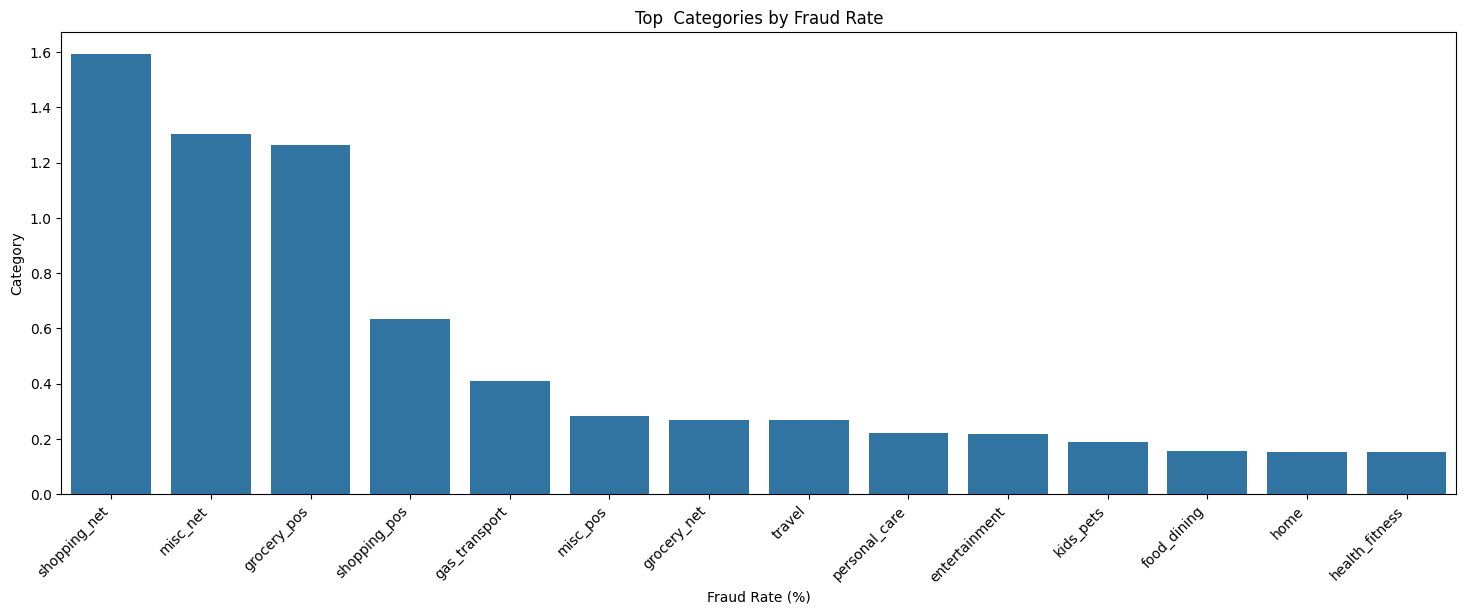

In [100]:
plt.figure(figsize=(18,6))

sns.barplot(category_stats,x=category_stats.index,y ="fraud_rate")
plt.title('Top  Categories by Fraud Rate')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Category')
plt.xticks(rotation=45, ha='right')
plt.show()

Fraud rates vary significantly across transaction categories. The shopping_net category exhibits the highest fraud rate (approximately 1.6%), followed by misc_net (1.3%) and grocery_pos (1.27%). Online transaction categories such as shopping_net and misc_net generally show higher fraud rates compared to most in-store transaction categories, indicating that online purchases may be more vulnerable to fraudulent activities. Categories such as food_dining, home, and health_fitness show relatively lower fraud rates, suggesting a lower risk of fraud in these transaction types.

### **fraud by state**

In [101]:
# Calculate and rank fraud rates across transaction states
state_stats = df.groupby('state').agg(
    total_transactions = ("is_fraud","count"),
    fraud_count = ("is_fraud","sum")
)
state_stats

state_stats['fraud_rate'] = (state_stats['fraud_count'] / state_stats['total_transactions']) * 100
# here excludin the lower transactions
state_stats = state_stats[state_stats['total_transactions'] >= 100]
state_stats = state_stats.sort_values(by="fraud_rate",ascending=False).head(10)

state_stats

,total_transactions,fraud_count,fraud_rate
state,,,
RI,745,15,2.013423
AK,2963,50,1.687479
OR,26408,197,0.745986
NH,11727,79,0.673659
VA,41756,273,0.653798
TN,24913,159,0.638221
NE,34425,216,0.627451
MN,45433,280,0.616292
NY,119419,730,0.611293


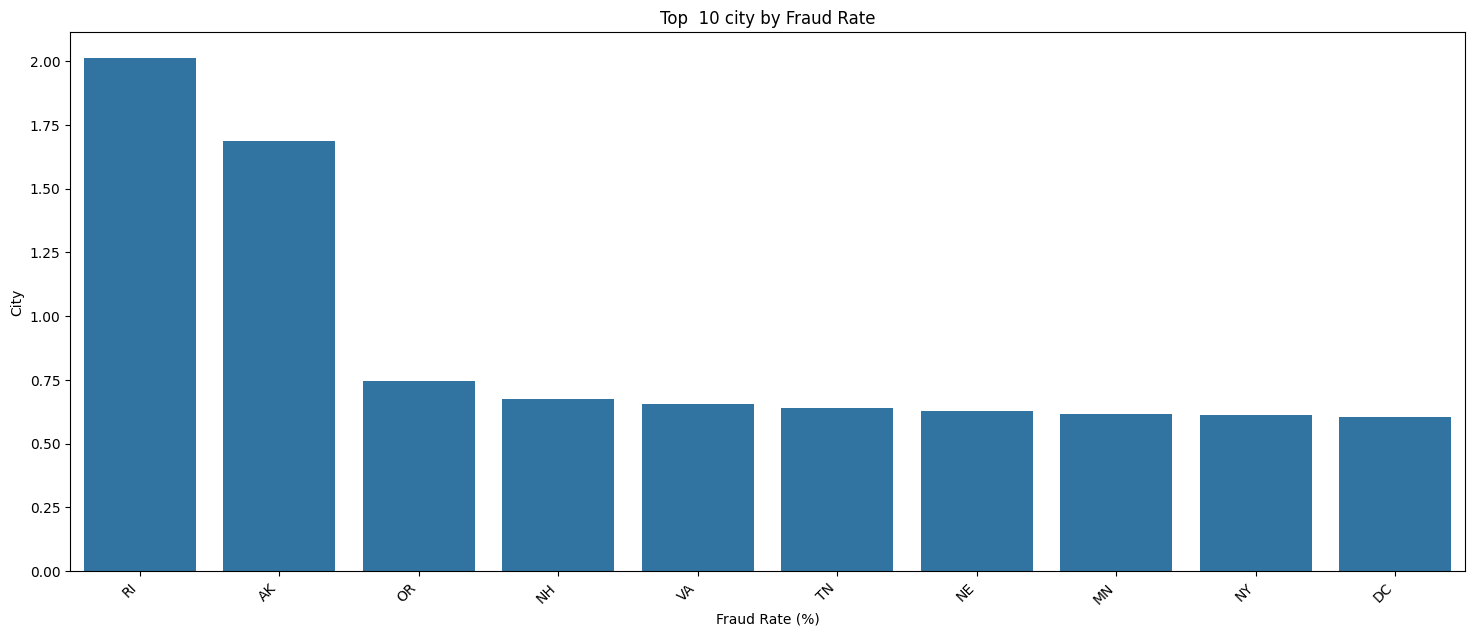

In [102]:
plt.figure(figsize=(18,7))

sns.barplot(state_stats,x=state_stats.index,y="fraud_rate")
plt.title('Top  10 city by Fraud Rate')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('City')
plt.xticks(rotation=45, ha='right')
plt.show()

### **fraud by job**

In [103]:
# Calculate and rank fraud rates across transaction Jobs
job_stats = df.groupby('job').agg(
    total_transactions = ("is_fraud","count"),
    fraud_count = ("is_fraud","sum")
)


job_stats['fraud_rate'] = (job_stats['fraud_count'] / job_stats['total_transactions']) * 100
# here excludin the lower transactions
job_stats = job_stats[job_stats['total_transactions'] >= 100]
job_stats = job_stats.sort_values(by="fraud_rate",ascending=False).head(10)

job_stats

,total_transactions,fraud_count,fraud_rate
job,,,
TEFL teacher,760,32,4.210526
Lawyer,757,28,3.698811
Community development worker,751,22,2.929427
"Accountant, chartered certified",751,21,2.796272
Horticultural consultant,746,19,2.546917
Clinical cytogeneticist,744,18,2.419355
Nature conservation officer,743,16,2.153432
"Geneticist, molecular",745,16,2.147651
Writer,741,15,2.024291


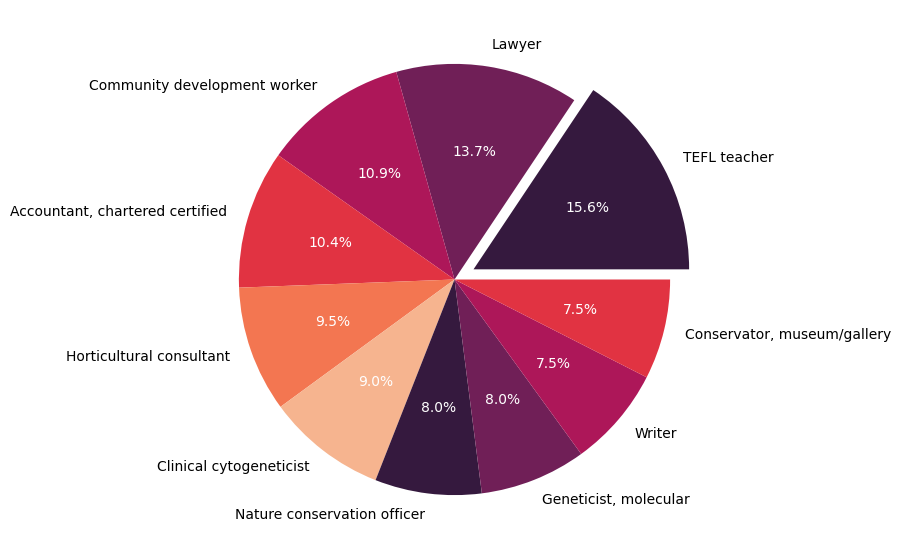

In [104]:
plt.figure(figsize=(18,7))
labels = job_stats.index.to_list()
data = job_stats['fraud_rate'].to_list()
colors = sns.color_palette("rocket")
explode = [0.1,0,0,0,0,0,0,0,0,0]
wedges, texts, autotexts = plt.pie(
    data,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%.1f%%'
)
# Percentage text inside pie
for autotext in autotexts:
    autotext.set_color('white')

# Labels outside pie
for text in texts:
    text.set_color('black')
plt.show()

### **fruad by cc_num**

In [105]:
#Calculate and rank fraud rates across transaction credit card number
ccNum_stats = df.groupby('cc_num').agg(
    total_transactions = ("is_fraud","count"),
    fraud_count = ("is_fraud","sum")
)
ccNum_stats

ccNum_stats['fraud_rate'] = (ccNum_stats['fraud_count'] / ccNum_stats['total_transactions']) * 100
# here excludin the lower transactions
ccNum_stats = ccNum_stats[ccNum_stats['total_transactions'] >= 100]
ccNum_stats = ccNum_stats.sort_values(by="fraud_rate",ascending=False).head(10)

ccNum_stats

,total_transactions,fraud_count,fraud_rate
cc_num,,,
30011465039817,743,16,2.153432
4725837176265195730,743,16,2.153432
2227671554547514,745,16,2.147651
4874006077381178,745,16,2.147651
676326610042,741,15,2.024291
6597248210463122,743,15,2.018843
3534093764340240,743,15,2.018843
36890292963032,743,15,2.018843
342360239917375,743,15,2.018843


Certain cardholders exhibit higher fraud rates than others, with the highest observed rates around 2.15%. However, since credit card numbers are unique identifiers, this feature is not suitable for direct modeling and is primarily useful for exploratory analysis.

### **bivariate analysis**

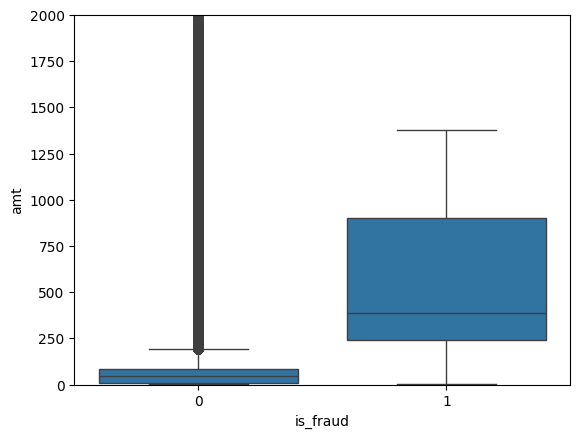

In [106]:
# Compare transaction amount distributions between fraudulent and non-fraudulent transactions
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.ylim(0, 2000)
plt.show()

The transaction amount distribution differs substantially between fraudulent and non-fraudulent transactions. Fraudulent transactions exhibit a significantly higher median transaction amount and a wider spread compared to non-fraudulent transactions. This indicates that high-value transactions are more likely to be associated with fraudulent activity, making transaction amount a potentially important feature for fraud detection.

### **univariate analysis**

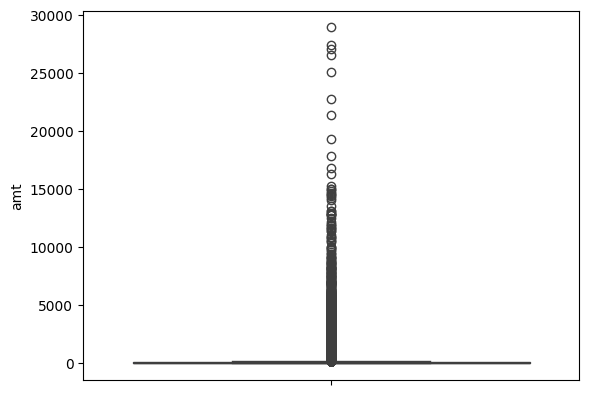

In [107]:
# Visualize the distribution of transaction amounts and identify outliers
sns.boxplot(y=df['amt'])
plt.show()

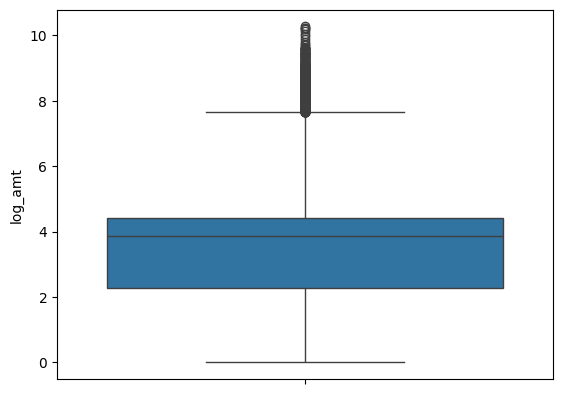

In [108]:
# logtransform
df["log_amt"] = np.log(df['amt']).round(3)
sns.boxplot(y=df['log_amt'])
plt.show()

In [109]:
print(df['amt'].skew())
print(df['log_amt'].skew())

40.81280917629574
-0.452044770388488


After applying a logarithmic transformation, the distribution of transaction amounts became substantially more symmetric, reducing the skewness from 40.81 to -0.45. Although a few outliers remain, their influence has been significantly reduced, resulting in a more balanced feature distribution.

### **correlation**

In [110]:
# Calculate the correlation of numerical features with the target variable
corr_target = df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

print(corr_target)

is_fraud      1.000000
amt           0.209308
log_amt       0.109170
lat           0.002904
merch_lat     0.002778
long          0.001022
merch_long    0.000999
city_pop      0.000325
cc_num       -0.001125
Name: is_fraud, dtype: float64


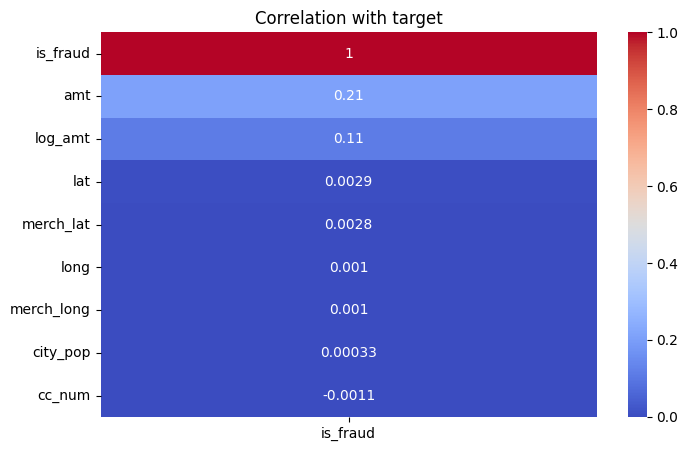

In [111]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True)[['is_fraud']]
    .sort_values(by='is_fraud', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation with target")
plt.show()

Transaction amount (amt) exhibits the highest positive correlation with the target variable (0.21), indicating that higher transaction amounts are more likely to be associated with fraudulent transactions. The log-transformed amount (log_amt) also shows a positive relationship with fraud, although weaker than the original amount. All other numerical features display correlations close to zero, suggesting a weak linear relationship with the target variable.

## **Feature Engineering**

### **transaction year month date created**

In [112]:
# Extract year, month, and weekday features from transaction timestamp
df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month_name()
df['weekday'] = df['trans_date_trans_time'].dt.day_name()

df[['trans_date_trans_time', 'year', 'month', 'weekday']]

,trans_date_trans_time,year,month,weekday
0,2019-01-01 00:00:18,2019,January,Tuesday
1,2019-01-01 00:00:44,2019,January,Tuesday
2,2019-01-01 00:00:51,2019,January,Tuesday
3,2019-01-01 00:01:16,2019,January,Tuesday
4,2019-01-01 00:03:06,2019,January,Tuesday
...,...,...,...,...
1852389,2020-12-31 23:59:07,2020,December,Thursday
1852390,2020-12-31 23:59:09,2020,December,Thursday
1852391,2020-12-31 23:59:15,2020,December,Thursday
1852392,2020-12-31 23:59:24,2020,December,Thursday


### **extracting Hour**

In [113]:
df['hour'] = df['trans_date_trans_time'].dt.hour

In [114]:
df[['trans_date_trans_time','year','month','weekday','hour']].head(5)

,trans_date_trans_time,year,month,weekday,hour
0,2019-01-01 00:00:18,2019,January,Tuesday,0
1,2019-01-01 00:00:44,2019,January,Tuesday,0
2,2019-01-01 00:00:51,2019,January,Tuesday,0
3,2019-01-01 00:01:16,2019,January,Tuesday,0
4,2019-01-01 00:03:06,2019,January,Tuesday,0


In [115]:
# Categorize transaction hours into different time periods of the day
def time_period(hour):
    if 22 <= hour or hour < 5:
        return 'Night(10pm - 5am)'
    elif 5 <= hour < 7:
        return 'Early Morning(5am - 7am)'
    elif 7 <= hour < 12:
        return 'Morning(7am - 12pm)'
    elif 12 <= hour < 17:
        return 'Afternoon(12pm - 5pm)'
    else:  # 17 <= hour < 22
        return 'Evening(5pm - 10pm)'

In [116]:
df['time_period'] = df['hour'].apply(time_period)

In [117]:
df[['year','month','weekday','hour','time_period']].head(5)

,year,month,weekday,hour,time_period
0,2019,January,Tuesday,0,Night(10pm - 5am)
1,2019,January,Tuesday,0,Night(10pm - 5am)
2,2019,January,Tuesday,0,Night(10pm - 5am)
3,2019,January,Tuesday,0,Night(10pm - 5am)
4,2019,January,Tuesday,0,Night(10pm - 5am)


In [118]:
df.drop(columns=['trans_date_trans_time'],inplace=True)

### **age calculation**

In [119]:
# Calculate customer age from date of birth
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = ((pd.Timestamp.today() - df['dob']).dt.days / 365.25).astype(int)
df.drop(columns=['dob'])
df[['dob','age']].head(5)

,dob,age
0,1988-03-09,38
1,1978-06-21,48
2,1962-01-19,64
3,1967-01-12,59
4,1986-03-28,40


In [120]:
print(df['age'].min())
print(df['age'].max())
print(df['age'].mean())

21
101
52.18086379031675


In [121]:
# Categorize customers into age groups based on their age
bins = [20, 35, 50, 65, 80, 105]
labels = [
    'Young Adult(20-35)',
    'Adult(35-50)',
    'Middle Aged(50-65)',
    'Senior(65-80)',
    'Elderly(80-105)'
]

df['age_period'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [122]:
df[['age_period','age']].head(5)

,age_period,age
0,Adult(35-50),38
1,Adult(35-50),48
2,Middle Aged(50-65),64
3,Middle Aged(50-65),59
4,Adult(35-50),40


In [123]:
df.head(4)

,cc_num,merchant,category,amt,gender,city,state,lat,long,city_pop,...,merch_long,is_fraud,log_amt,year,month,weekday,hour,time_period,age,age_period
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,...,-82.048315,0,1.603,2019,January,Tuesday,0,Night(10pm - 5am),38,Adult(35-50)
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,...,-118.186462,0,4.675,2019,January,Tuesday,0,Night(10pm - 5am),48,Adult(35-50)
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,...,-112.154481,0,5.394,2019,January,Tuesday,0,Night(10pm - 5am),64,Middle Aged(50-65)
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,...,-112.561071,0,3.807,2019,January,Tuesday,0,Night(10pm - 5am),59,Middle Aged(50-65)


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column       Dtype         
---  ------       -----         
 0   cc_num       int64         
 1   merchant     object        
 2   category     object        
 3   amt          float64       
 4   gender       object        
 5   city         object        
 6   state        object        
 7   lat          float64       
 8   long         float64       
 9   city_pop     int64         
 10  job          object        
 11  dob          datetime64[ns]
 12  merch_lat    float64       
 13  merch_long   float64       
 14  is_fraud     int64         
 15  log_amt      float64       
 16  year         int32         
 17  month        object        
 18  weekday      object        
 19  hour         int32         
 20  time_period  object        
 21  age          int64         
 22  age_period   category      
dtypes: category(1), datetime64[ns](1), float64(6), int32(2), 

### **creating distance between merchat and consumer using Haversine formula**

In [125]:
# Calculate the distance between customer and merchant locations using the Haversine formula
R = 6371  # Earth radius in km

lat1 = np.radians(df['lat'])
lon1 = np.radians(df['long'])
lat2 = np.radians(df['merch_lat'])
lon2 = np.radians(df['merch_long'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df['distance_km'] = R * c
df['distance_km'] = df['distance_km'].round(1)

In [126]:
df[['merchant','distance_km','city','state']]

,merchant,distance_km,city,state
0,"fraud_Rippin, Kub and Mann",78.6,Moravian Falls,NC
1,"fraud_Heller, Gutmann and Zieme",30.2,Orient,WA
2,fraud_Lind-Buckridge,108.2,Malad City,ID
3,"fraud_Kutch, Hermiston and Farrell",95.7,Boulder,MT
4,fraud_Keeling-Crist,77.6,Doe Hill,VA
...,...,...,...,...
1852389,fraud_Reilly and Sons,77.0,Luray,MO
1852390,fraud_Hoppe-Parisian,100.1,Lake Jackson,TX
1852391,fraud_Rau-Robel,80.8,Burbank,WA
1852392,fraud_Breitenberg LLC,52.9,Mesa,ID


In [127]:
print(df['distance_km'].min())
print(df['distance_km'].max())
print(df['distance_km'].mean())

0.0
152.1
76.11170053455156


In [128]:
df['distance_km'].describe()

,distance_km
count,1.852394e+06
mean,7.611170e+01
std,2.911696e+01
min,0.000000e+00
25%,5.530000e+01
50%,7.820000e+01
75%,9.850000e+01
max,1.521000e+02


In [129]:
# Categorize transaction distances into distance-based groups
bins = [0, 55.3, 78.2, 98.5, 152.1]
labels = ['Near', 'Moderate', 'Far', 'Very Far']

df['distance_group'] = pd.cut(
    df['distance_km'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

## **Analysing wiht newly created features**

In [130]:
# Calculate fraud percentage within each distance group
pd.crosstab(
    df['distance_group'],
    df['is_fraud'],
    normalize='index'
) * 100

is_fraud,0,1
distance_group,,
Near,99.483843,0.516157
Moderate,99.471939,0.528061
Far,99.477716,0.522284
Very Far,99.482502,0.517498


The fraud rate remained nearly constant across all distance groups (≈0.52%), indicating that transaction distance does not appear to be a strong predictor of fraudulent activity.

In [131]:
# Calculate fraud percentage within each age group
pd.crosstab(
    df['age_period'],
    df['is_fraud'],
    normalize='index'
) * 100

is_fraud,0,1
age_period,,
Young Adult(20-35),99.483143,0.516857
Adult(35-50),99.592375,0.407625
Middle Aged(50-65),99.441708,0.558292
Senior(65-80),99.400532,0.599468
Elderly(80-105),99.242248,0.757752


Fraud rates tend to increase with age. The Elderly (80–105) age group exhibited the highest fraud rate (0.76%), while Adults (35–50) showed the lowest fraud rate (0.41%). This suggests age may have a modest relationship with fraudulent transaction behavior.

In [132]:
# Calculate and rank fraud rates across customer age groups
age_stats = df.groupby('age_period', observed=False).agg(
    total_transactions=("is_fraud", "count"),
    fraud_count=("is_fraud", "sum")
)

age_stats['fraud_rate'] = (
    age_stats['fraud_count']
    / age_stats['total_transactions']
) * 100

age_stats = age_stats.sort_values(
    'fraud_rate',
    ascending=False
)

age_stats

,total_transactions,fraud_count,fraud_rate
age_period,,,
Elderly(80-105),137908,1045,0.757752
Senior(65-80),271741,1629,0.599468
Middle Aged(50-65),493469,2755,0.558292
Young Adult(20-35),322720,1668,0.516857
Adult(35-50),626556,2554,0.407625


Age appears to have a modest relationship with fraud. Elderly customers (80–105 years) exhibit the highest fraud rate (0.76%), whereas adults aged 35–50 show the lowest fraud rate (0.41%). This indicates that fraud risk tends to increase among older age groups.

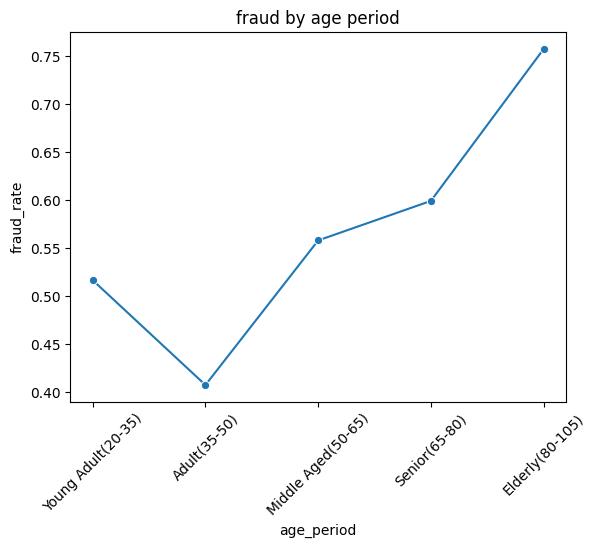

In [133]:
sns.lineplot(
    x=age_stats.index,
    y=age_stats['fraud_rate'],
    marker='o'
)

plt.xticks(rotation=45)
plt.title("fraud by age period")
plt.show()

In [134]:
# Calculate and rank fraud rates across different time periods of the day
time_period_stats = df.groupby('time_period', observed=False).agg(
    total_transactions=("is_fraud", "count"),
    fraud_count=("is_fraud", "sum")
)

time_period_stats['fraud_rate'] = (
    time_period_stats['fraud_count']
    / time_period_stats['total_transactions']
) * 100

time_period_stats = time_period_stats.sort_values(
    'fraud_rate',
    ascending=False
)

time_period_stats

,total_transactions,fraud_count,fraud_rate
time_period,,,
Night(10pm - 5am),494959,8230,1.662764
Early Morning(5am - 7am),120494,134,0.111209
Evening(5pm - 10pm),467818,509,0.108803
Afternoon(12pm - 5pm),467603,475,0.101582
Morning(7am - 12pm),301520,303,0.100491


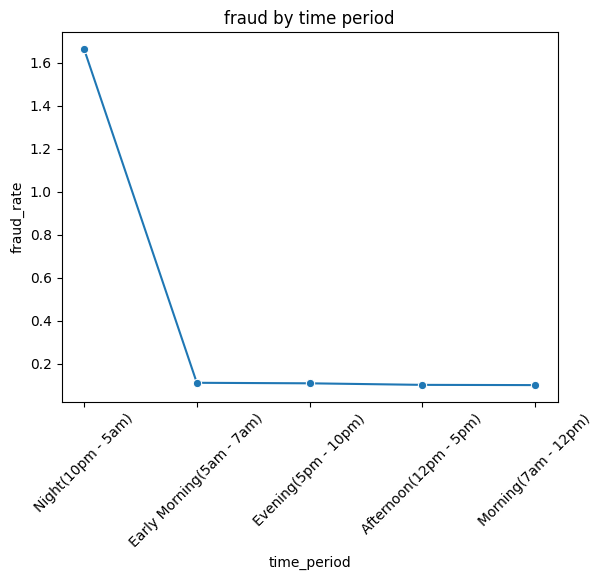

In [135]:
sns.lineplot(
    x=time_period_stats.index,
    y=time_period_stats['fraud_rate'],
    marker='o'
)

plt.xticks(rotation=45)
plt.title("fraud by time period")
plt.show()

Transaction time shows a strong relationship with fraud. Transactions occurring during the night period (10 PM–5 AM) have a fraud rate of 1.66%, significantly higher than all other periods (≈0.10–0.11%). This suggests that nighttime transactions are substantially more likely to be fraudulent.

### **month analyzing**

In [136]:
pd.crosstab(
    df['month'],
    df['is_fraud'],
    normalize='index'
)* 100

is_fraud,0,1
month,,
April,99.497666,0.502334
August,99.547462,0.452538
December,99.697076,0.302924
February,99.126535,0.873465
January,99.189321,0.810679
July,99.621906,0.378094
June,99.527805,0.472195
March,99.347655,0.652345
May,99.363404,0.636596


Fraud activity varies across months, with February (0.87%) and January (0.81%) exhibiting the highest fraud rates, while December shows the lowest (0.30%). This suggests a seasonal pattern in fraudulent transactions, although the effect is less pronounced than the variation observed across transaction time periods.

### **weekday analysing**

In [137]:
ct = pd.crosstab(
    df['weekday'],
    df['is_fraud'],
    normalize='index'
)* 100
ct.sort_values(by=1,ascending=False)


is_fraud,0,1
weekday,,
Friday,99.360232,0.639768
Thursday,99.362971,0.637029
Wednesday,99.388298,0.611702
Saturday,99.432809,0.567191
Tuesday,99.531701,0.468299
Sunday,99.537356,0.462644
Monday,99.598287,0.401713


Fraud rates vary moderately across weekdays, with Friday (0.64%) and Thursday (0.64%) showing the highest fraud incidence, while Monday exhibits the lowest (0.40%). This suggests a mild relationship between transaction weekday and fraudulent activity.

### **droping reduandant columns**

In [138]:
# Remove identifier, intermediate, and redundant features after feature engineering
df.drop(columns=["cc_num","dob","age_period","distance_group","lat","long","merch_lat","merch_long","log_amt"],inplace=True)

In [139]:
# df.info()

In [140]:
df.groupby('is_fraud')[['amt','age','city_pop','distance_km']].mean()

,amt,age,city_pop,distance_km
is_fraud,,,,
0,67.651278,52.166778,88636.579284,76.110943
1,530.661412,54.870376,89998.422961,76.256419


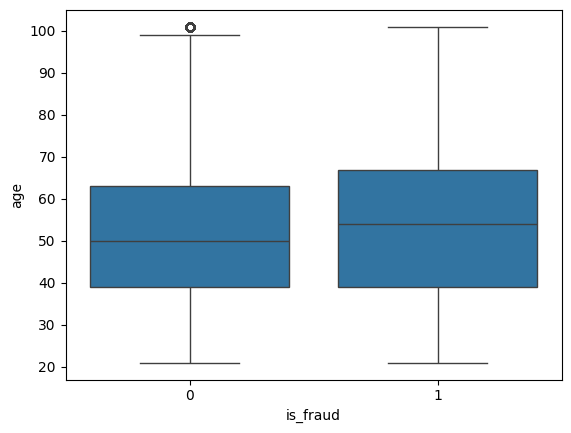

In [141]:
sns.boxplot(x='is_fraud', y='age', data=df)
plt.show()

Fraudulent transactions are associated with slightly older customers. The median age for fraudulent transactions is higher than for legitimate transactions; however, substantial overlap exists between the distributions, indicating that age alone is not a strong discriminator of fraud.

## **Model Creation**

### **dependent and independent variables**

In [142]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

#### **train test split**

In [143]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [144]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1296675, 15)
(555719, 15)
(1296675,)
(555719,)


In [145]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(include=['number']).columns

In [146]:
# Create a preprocessing pipeline for categorical and numerical features
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [148]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#### **<font color="red" size="6">XGBOOST CLASS WEIGHT</font>**

In [ ]:
# for xgboost class balanced done using like this
# neg = y_train.value_counts()[0]
# pos = y_train.value_counts()[1]

# scale_pos_weight = neg / pos

In [ ]:
# from xgboost import XGBClassifier
# pipe_xgb_balanced = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', XGBClassifier(
#         n_estimators=100,
#         max_depth=3,
#         learning_rate=0.05,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         scale_pos_weight=scale_pos_weight,
#         random_state=42,
#         eval_metric='logloss'
#     ))
# ])

In [ ]:
# pipe_xgb_balanced.fit(X_train, y_train)

In [ ]:
# y_pred_xg = pipe_xgb_balanced.predict(X_test)

In [ ]:
# print("Train:", pipe_xgb_balanced.score(X_train, y_train))
# print("Test :", pipe_xgb_balanced.score(X_test, y_test))

In [ ]:
# print(classification_report(y_test, y_pred_xg))

In [ ]:
# print(precision_score(y_test, y_pred_xg))
# print(recall_score(y_test, y_pred_xg))
# print(f1_score(y_test, y_pred_xg))

#### **<font color="red" size="6">XGBOOST Using SMOTE</font>**

In [149]:
# Build a pipeline with preprocessing, SMOTE oversampling, and XGBoost classification
pipe_xgb_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipe_xgb_smote.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'month',
       'weekday', 'time_period'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['amt', 'city_pop', 'year', 'hour', 'age', 'distance_km'], dtype='object'))])),
                ('smote', SMOTE(random_state=...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [150]:
# Generate predictions on the test set using the trained XGBoost-SMOTE pipeline
y_pred_xgb_smote = pipe_xgb_smote.predict(X_test)

In [151]:
print("Train:", pipe_xgb_smote.score(X_train, y_train))
print("Test :", pipe_xgb_smote.score(X_test, y_test))

Train: 0.9695490388879249
Test : 0.9696177384613447


In [152]:
# Generate a detailed classification report for the XGBoost-SMOTE model
print(classification_report(y_test, y_pred_xgb_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    552781
           1       0.14      0.89      0.24      2938

    accuracy                           0.97    555719
   macro avg       0.57      0.93      0.61    555719
weighted avg       0.99      0.97      0.98    555719



In [153]:
# Generate the confusion matrix for the XGBoost-SMOTE model predictions
cm = confusion_matrix(y_test, y_pred_xgb_smote)
print(cm)

[[536224  16557]
 [   327   2611]]


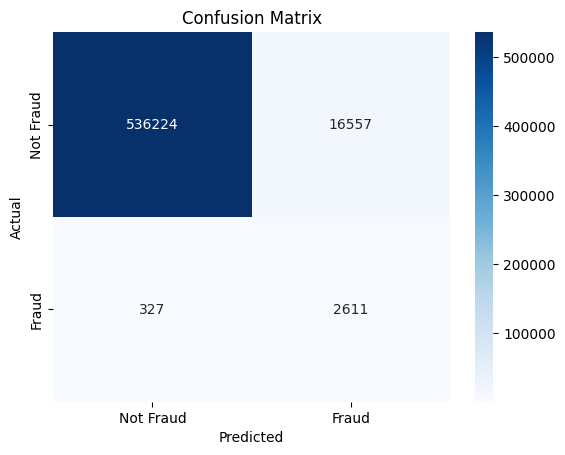

In [154]:
# Visualize the confusion matrix using a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [155]:
print("Precision:", cm[1][1] / (cm[1][1] + cm[0][1]) * 100)
print("Recall:", cm[1][1] / (cm[1][1] + cm[1][0]) * 100)

Precision: 13.621661101836393
Recall: 88.86997957794418


In [156]:
# Store evaluation metrics for different classification thresholds
results = []

# Generate fraud probability scores from the final model
y_prob = pipe_xgb_smote.predict_proba(X_test)[:, 1]

# Evaluate model performance across multiple threshold values
for threshold in np.arange(0.1, 1.0, 0.1):

    # Convert probabilities into class predictions
    # based on the current threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate and store evaluation metrics
    results.append([
        threshold,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

# Create a DataFrame to compare Precision, Recall,
# and F1-Score at different thresholds
threshold_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Precision', 'Recall', 'F1']
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.017691,0.965623,0.034746
1,0.2,0.025608,0.960858,0.049886
2,0.3,0.074830,0.926821,0.138480
3,0.4,0.084157,0.918312,0.154185
4,0.5,0.136217,0.888700,0.236225
5,0.6,0.299303,0.745405,0.427109
6,0.7,0.337000,0.708986,0.456848
7,0.8,0.409200,0.638870,0.498870
8,0.9,0.455293,0.622192,0.525816


In [158]:
# Generate fraud predictions using a 0.9 probability threshold and create a results table
y_prob = pipe_xgb_smote.predict_proba(X_test)[:, 1]

y_pred_02 = (y_prob >= 0.9).astype(int)

results_df = pd.DataFrame({
    'Actual': y_test,
    'Fraud_Probability': y_prob,
    'Predicted': y_pred_02
})

results_df['Prediction_Label'] = results_df['Predicted'].map({
    0: 'Not Fraud',
    1: 'Fraud'
})

results_df.head(20)

,Actual,Fraud_Probability,Predicted,Prediction_Label
1541144,0,0.036726,0,Not Fraud
1731581,0,0.038866,0,Not Fraud
354659,0,0.036726,0,Not Fraud
1493788,0,0.178580,0,Not Fraud
468148,0,0.038866,0,Not Fraud
1389854,0,0.032639,0,Not Fraud
1760906,0,0.250681,0,Not Fraud
469447,0,0.170579,0,Not Fraud
1835018,0,0.036726,0,Not Fraud
240727,0,0.031506,0,Not Fraud


AUC Score: 0.977097538121893


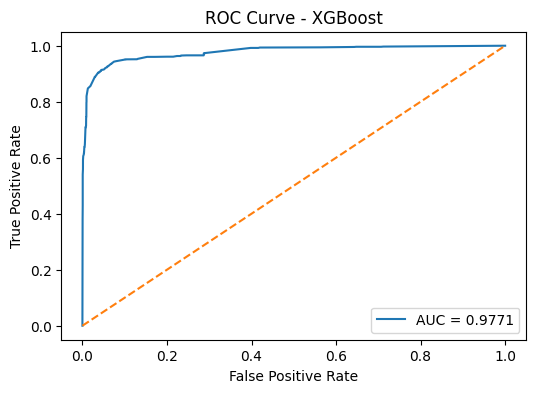

In [159]:
from sklearn.metrics import roc_curve, roc_auc_score
# Probability of class 1 (fraud)
y_prob = pipe_xgb_smote.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

#### **<font color="red" size="6">XGBOOST USING SMOTE AND Select from model</font>**

In [160]:
# Create a pipeline with preprocessing, SMOTE, feature selection, and XGBoost classification
from sklearn.feature_selection import SelectFromModel

pipeline2 = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    # Select important features based on XGBoost feature importance scores
    ('feature_selection',
     SelectFromModel(XGBClassifier(
         n_estimators=100, # Number of trees used for feature selection
         random_state=42, #Ensures reproducible results
         eval_metric='logloss' #Evaluation metric during training
     ))),
    # Train the final XGBoost classifier
    ('model', XGBClassifier(
         n_estimators=100, # Number of boosting trees
         max_depth=3, #Maximum depth of each tree
         learning_rate=0.05, # Controls contribution of each tree
         random_state=42, # Ensures reproducible results
         eval_metric='logloss' # Evaluation metric during training
    ))
])

In [161]:
pipeline2.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'month',
       'weekday', 'time_period'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['amt', 'city_pop', 'year', 'hour', 'age', 'distance_km'], dtype='object'))])),
                ('smote', SMOTE(random_state=...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [162]:
# Retrieve and display the features selected by the feature selection step
selector = pipeline2.named_steps['feature_selection']


# Get feature names after preprocessing
feature_names = pipeline2.named_steps['preprocessor'].get_feature_names_out()

# Extract only the selected features
selected_features = feature_names[selector.get_support()]

print(selected_features)
print("Number of selected features:", len(selected_features))

['cat__merchant_fraud_Abbott-Steuber'
 'cat__merchant_fraud_Ankunding-Carroll'
 'cat__merchant_fraud_Balistreri-Nader'
 'cat__merchant_fraud_Bartoletti-Wunsch' 'cat__merchant_fraud_Beer-Jast'
 'cat__merchant_fraud_Bernhard-Lesch' 'cat__merchant_fraud_Block Group'
 'cat__merchant_fraud_Botsford Ltd' 'cat__merchant_fraud_Boyer-Haley'
 'cat__merchant_fraud_Bradtke, Torp and Bahringer'
 'cat__merchant_fraud_Buckridge PLC'
 'cat__merchant_fraud_Connelly, Reichert and Fritsch'
 'cat__merchant_fraud_Corwin-Romaguera'
 'cat__merchant_fraud_Cremin, Hamill and Reichel'
 'cat__merchant_fraud_Crona and Sons' 'cat__merchant_fraud_Daugherty LLC'
 'cat__merchant_fraud_Ernser-Lynch' 'cat__merchant_fraud_Fadel Inc'
 'cat__merchant_fraud_Fahey Inc'
 'cat__merchant_fraud_Graham, Hegmann and Hammes'
 'cat__merchant_fraud_Hagenes, Hermann and Stroman'
 'cat__merchant_fraud_Hahn, Bahringer and McLaughlin'
 'cat__merchant_fraud_Haley Group' 'cat__merchant_fraud_Halvorson Group'
 'cat__merchant_fraud_Harris, 

In [163]:
print("Original features:", len(feature_names))
print("Selected features:", selector.get_support().sum())

Original features: 2193
Selected features: 178


In [164]:
# Extract and rank feature importance scores from the XGBoost feature selection model
importances = selector.estimator_.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feature_imp_df.head(20)

,Feature,Importance
2186,cat__time_period_Night(10pm - 5am),0.099644
2187,num__amt,0.088204
697,cat__category_grocery_pos,0.035864
694,cat__category_food_dining,0.033951
24,cat__merchant_fraud_Bartoletti-Wunsch,0.023158
699,cat__category_home,0.022025
2178,cat__weekday_Sunday,0.020914
2173,cat__month_October,0.018201
695,cat__category_gas_transport,0.017604
703,cat__category_personal_care,0.017527


In [165]:
y_pred2 = pipeline2.predict(X_test)

In [166]:
print("Train:", pipeline2.score(X_train, y_train))
print("Test :", pipeline2.score(X_test, y_test))

Train: 0.9856139742032506
Test : 0.9858039764701225


In [167]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    552781
           1       0.25      0.85      0.39      2938

    accuracy                           0.99    555719
   macro avg       0.63      0.92      0.69    555719
weighted avg       1.00      0.99      0.99    555719



In [168]:
cm = confusion_matrix(y_test, y_pred2)
print(cm)

[[545329   7452]
 [   437   2501]]


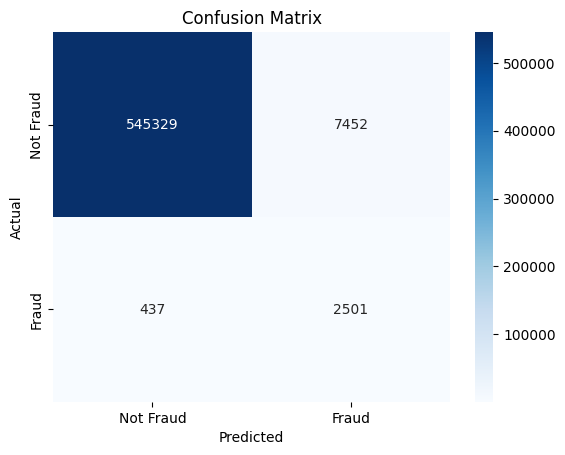

In [169]:
# Visualization of Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [170]:
print("Precision:", cm[1][1] / (cm[1][1] + cm[0][1]) * 100)
print("Recall:", cm[1][1] / (cm[1][1] + cm[1][0]) * 100)

Precision: 25.128102079774944
Recall: 85.12593601089176


Applying SelectFromModel reduced irrelevant features and improved the model's ability to distinguish fraudulent transactions. While recall decreased slightly, precision increased substantially, resulting in a significant improvement in F1 score from 0.23 to 0.44.

In [171]:
# Store evaluation metrics for different classification thresholds
results = []

# Generate fraud probability scores from the final model
y_prob = pipeline2.predict_proba(X_test)[:, 1]

# Evaluate model performance across multiple threshold values
for threshold in np.arange(0.1, 1.0, 0.1):

    # Convert probabilities into class predictions
    # based on the current threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate and store evaluation metrics
    results.append([
        threshold,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])
# Create a DataFrame to compare Precision, Recall,
# and F1-Score at different thresholds
threshold_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Precision', 'Recall', 'F1']
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.017690,0.965623,0.034744
1,0.2,0.022632,0.960858,0.044223
2,0.3,0.075281,0.926821,0.139252
3,0.4,0.090024,0.915589,0.163929
4,0.5,0.251281,0.851259,0.388023
5,0.6,0.298774,0.746426,0.426737
6,0.7,0.340382,0.739619,0.466209
7,0.8,0.405557,0.640912,0.496768
8,0.9,0.454500,0.622192,0.525287


In [172]:
y_prob = pipeline2.predict_proba(X_test)[:, 1]

y_pred_02 = (y_prob >= 0.9).astype(int)

results_df = pd.DataFrame({
    'Actual': y_test,
    'Fraud_Probability': y_prob,
    'Predicted': y_pred_02
})

results_df['Prediction_Label'] = results_df['Predicted'].map({
    0: 'Not Fraud',
    1: 'Fraud'
})

results_df.head(20)

,Actual,Fraud_Probability,Predicted,Prediction_Label
1541144,0,0.037156,0,Not Fraud
1731581,0,0.037163,0,Not Fraud
354659,0,0.037156,0,Not Fraud
1493788,0,0.171450,0,Not Fraud
468148,0,0.037163,0,Not Fraud
1389854,0,0.034959,0,Not Fraud
1760906,0,0.247262,0,Not Fraud
469447,0,0.202048,0,Not Fraud
1835018,0,0.037156,0,Not Fraud
240727,0,0.033828,0,Not Fraud


AUC Score: 0.9764066254145267


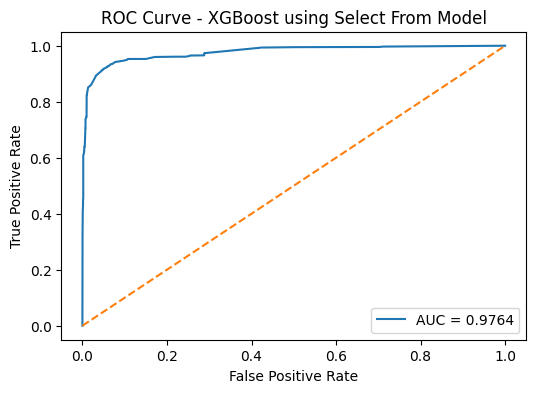

In [173]:

# Probability of class 1 (fraud)
y_prob = pipeline2.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost using Select From Model')
plt.legend()
plt.show()

Feature selection using SelectFromModel reduced the feature space from 2193 to 184 features (91.6% reduction). Despite this substantial reduction, the ROC-AUC score remained nearly unchanged (0.9771 vs 0.9754), demonstrating that the selected features retained most of the predictive information while significantly simplifying the model.

#### **Using Random SearchCV**

In [174]:
from sklearn.model_selection import RandomizedSearchCV

# Perform Randomized Search to find optimal XGBoost hyperparameters
param_dist = {
    'model__n_estimators': [100, 200], # Number of bossting trees
    'model__max_depth': [3, 5], # Tree depth
    'model__learning_rate': [0.05, 0.1] #learning rate for bossting
}

random_search = RandomizedSearchCV(
    estimator=pipeline2,
    param_distributions=param_dist,
    n_iter=3,          # only 3 random combinations
    cv=2,              # only 2 folds
    scoring='f1',      # optimized based socre f1
    verbose=3,         # show detailed progress
    random_state=42,
    n_jobs=-1         # use all avialbe cpu cores
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)



Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best Parameters:
{'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1}

Best CV F1 Score:
0.5131532367424616


In [175]:
# best pipeline
best_pipeline = random_search.best_estimator_

In [176]:
y_pred3 = best_pipeline.predict(X_test)

In [177]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    552781
           1       0.38      0.82      0.52      2938

    accuracy                           0.99    555719
   macro avg       0.69      0.90      0.76    555719
weighted avg       1.00      0.99      0.99    555719



In [178]:
cm = confusion_matrix(y_test, y_pred3)
print(cm)

[[548868   3913]
 [   541   2397]]


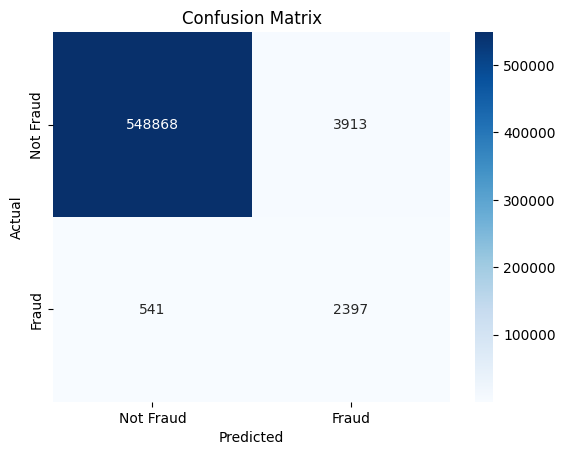

In [179]:
# Visualize the confusion matrix to evaluate
# the classification performance of the final model
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)
# Add axis labels and chart title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [180]:
print("Precision:", cm[1][1] / (cm[1][1] + cm[0][1]) * 100)
print("Recall:", cm[1][1] / (cm[1][1] + cm[1][0]) * 100)

Precision: 37.98732171156894
Recall: 81.58611300204221


In [181]:
# Store evaluation metrics for different classification thresholds
results = []

# Generate fraud probability scores from the final model
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Evaluate model performance across multiple threshold values
for threshold in np.arange(0.1, 1.0, 0.1):

    # Convert probabilities into class predictions
    # based on the current threshold
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate and store evaluation metrics
    results.append([
        threshold,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])
# Create a DataFrame to compare Precision, Recall,
# and F1-Score at different thresholds
threshold_df = pd.DataFrame(
    results,
    columns=['Threshold', 'Precision', 'Recall', 'F1']
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.083484,0.942478,0.153382
1,0.2,0.137633,0.917291,0.239353
2,0.3,0.293059,0.847856,0.435566
3,0.4,0.348794,0.821647,0.489705
4,0.5,0.379873,0.815861,0.518382
5,0.6,0.414740,0.781484,0.541893
6,0.7,0.509180,0.745745,0.605165
7,0.8,0.581858,0.637509,0.608413
8,0.9,0.752458,0.599047,0.667046


In [182]:
# Generate fraud probability scores for each transaction
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Apply a custom threshold of 0.9 to classify transactions
# as Fraud (1) or Not Fraud (0)
y_pred_02 = (y_prob >= 0.9).astype(int)

# Create a DataFrame containing actual labels,
# predicted fraud probabilities, and predicted classes
results_df = pd.DataFrame({
    'Actual': y_test,
    'Fraud_Probability': y_prob,
    'Predicted': y_pred_02
})

# Convert numeric predictions into readable labels
results_df['Prediction_Label'] = results_df['Predicted'].map({
    0: 'Not Fraud',
    1: 'Fraud'
})

results_df.head(20)

,Actual,Fraud_Probability,Predicted,Prediction_Label
1541144,0,0.005116,0,Not Fraud
1731581,0,0.001622,0,Not Fraud
354659,0,0.005116,0,Not Fraud
1493788,0,0.010123,0,Not Fraud
468148,0,0.009228,0,Not Fraud
1389854,0,0.003021,0,Not Fraud
1760906,0,0.065925,0,Not Fraud
469447,0,0.069383,0,Not Fraud
1835018,0,0.004324,0,Not Fraud
240727,0,0.005776,0,Not Fraud


AUC Score: 0.9838729022280212


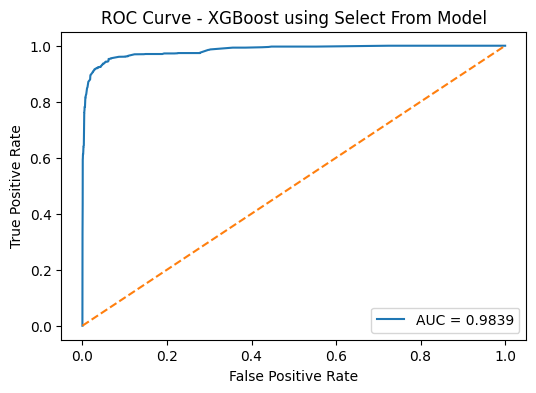

In [183]:

# Probability of class 1 (fraud)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost using Select From Model')
plt.legend()
plt.show()

#### **<font color="red" size="6">Model Comparision</font>**

In [184]:
# Reading the final clean cv file
import pandas as pd
clean_df = pd.read_csv('/content/drive/MyDrive/Credit Card Fraud Datasets/final_cc.csv')
clean_df.head(3)

,merchant,category,amt,gender,city,state,city_pop,job,is_fraud,year,month,weekday,hour,time_period,age,distance_km
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,3495,"Psychologist, counselling",0,2019,January,Tuesday,0,Night(10pm - 5am),38,78.6
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,0,2019,January,Tuesday,0,Night(10pm - 5am),48,30.2
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,4154,Nature conservation officer,0,2019,January,Tuesday,0,Night(10pm - 5am),64,108.2


In [185]:
# loading the models

import joblib

logistic_reg_classweight = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/logisticreg_class_wgt.pkl")
pipeline_xgb_classbalance = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/pipe_xgb_balanced.pkl")
pipeline_xgb_smote = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/pipe_xgb_smote.pkl")
pipeline_xgb_smote_selectionmodel_randomsearchCv = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/pipe_xgboost_smt_sm_rscv.pkl")
pipeline_xgb_smote_selectionmodel = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/pipeline_xgb_smt_sm.pkl")
pipeline_randomforsest_classweightbalance = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/rf_classet_pipeline.pkl")
pipeline_randomforest_smote = joblib.load("/content/drive/MyDrive/Credit Card Fraud Datasets/rf_smote_pipeline.pkl")

In [186]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,roc_auc_score

models = [logistic_reg_classweight,pipeline_xgb_classbalance,pipeline_xgb_smote,pipeline_xgb_smote_selectionmodel_randomsearchCv,pipeline_xgb_smote_selectionmodel,pipeline_randomforsest_classweightbalance,pipeline_randomforest_smote]

In [187]:
from sklearn.model_selection import train_test_split
X = clean_df.drop(columns=['is_fraud'])
y = clean_df['is_fraud']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [188]:
# Initialize a dictionary to store evaluation metrics
# for all trained machine learning models

dt = {
   "precision": [],
   "recall": [],
   "f1": [],
   "auc": []
}

# Iterate through each trained model
for i in models:

    # Generate class predictions
    y_pred = i.predict(X_test)

    # Generate probability predictions for ROC-AUC calculation
    y_prob = i.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Store the calculated metrics in the dictionary
    dt["precision"].append(precision)
    dt["recall"].append(recall)
    dt["f1"].append(f1)
    dt["auc"].append(auc)

In [189]:
dt

{'precision': [0.04395934600088378,
  0.10651180502665651,
  0.180955100292669,
  0.40194761584956346,
  0.2964504283965728,
  0.038310569082139596,
  0.04274033232061813],
 'recall': [0.8464942137508509,
  0.9520081688223281,
  0.8628318584070797,
  0.8148400272294077,
  0.8243703199455412,
  0.9002722940776038,
  0.7756977535738597],
 'f1': [0.08357837783341455,
  0.19158846496335366,
  0.2991679943352806,
  0.5383404542388127,
  0.4360821029888369,
  0.07349365787243502,
  0.08101670814077497],
 'auc': [np.float64(0.9493897462872455),
  np.float64(0.9892918674621787),
  np.float64(0.9777125070853909),
  np.float64(0.9833326415325282),
  np.float64(0.9754404497314895),
  np.float64(0.9569826349012277),
  np.float64(0.9422872680105902)]}

In [190]:
# Create a DataFrame to compare the performance of all trained models
# using Precision, Recall, F1-Score, and ROC-AUC metrics
df = pd.DataFrame(
    dt,
    index = ["logistic_reg_classweight","pipeline_xgb_classbalance","pipeline_xgb_smote","pipeline_xgb_smote_selectionmodel_randomsearchCv","pipeline_xgb_smote_selectionmodel","pipeline_randomforsest_classweightbalance","pipeline_randomforest_smote"]
)
df

,precision,recall,f1,auc
logistic_reg_classweight,0.043959,0.846494,0.083578,0.949390
pipeline_xgb_classbalance,0.106512,0.952008,0.191588,0.989292
pipeline_xgb_smote,0.180955,0.862832,0.299168,0.977713
pipeline_xgb_smote_selectionmodel_randomsearchCv,0.401948,0.814840,0.538340,0.983333
pipeline_xgb_smote_selectionmodel,0.296450,0.824370,0.436082,0.975440
pipeline_randomforsest_classweightbalance,0.038311,0.900272,0.073494,0.956983
pipeline_randomforest_smote,0.042740,0.775698,0.081017,0.942287


In [191]:
# sort by f1 score
df.sort_values(by="f1",ascending=False)

,precision,recall,f1,auc
pipeline_xgb_smote_selectionmodel_randomsearchCv,0.401948,0.814840,0.538340,0.983333
pipeline_xgb_smote_selectionmodel,0.296450,0.824370,0.436082,0.975440
pipeline_xgb_smote,0.180955,0.862832,0.299168,0.977713
pipeline_xgb_classbalance,0.106512,0.952008,0.191588,0.989292
logistic_reg_classweight,0.043959,0.846494,0.083578,0.949390
pipeline_randomforest_smote,0.042740,0.775698,0.081017,0.942287
pipeline_randomforsest_classweightbalance,0.038311,0.900272,0.073494,0.956983


**Insights from Model Comparison**

- Among all the evaluated models, the XGBoost model with SMOTE, SelectFromModel feature selection, and RandomizedSearchCV achieved the best overall performance with an F1-score of 0.538 and ROC-AUC of 0.983.

- Applying feature selection improved model performance significantly. The F1-score increased from 0.299 (XGBoost + SMOTE) to 0.436 (XGBoost + SMOTE + SelectFromModel), while reducing the feature space from 2193 to 184 features.

- Hyperparameter tuning using RandomizedSearchCV further improved the F1-score from 0.436 to 0.538 and increased precision from 29.6% to 40.2%, demonstrating the effectiveness of model optimization.

- Although the XGBoost model with class balancing achieved the highest ROC-AUC score (0.989), its F1-score was considerably lower (0.192), indicating that ROC-AUC alone is not sufficient for selecting the best fraud detection model.

- Logistic Regression and Random Forest models showed lower precision and F1-scores compared to XGBoost-based models, making them less suitable for this fraud detection task.

- The final selected model provides the best balance between precision and recall, successfully identifying fraudulent transactions while minimizing false positive predictions.